In [1]:
import datajoint as dj
dj.config.load('C:\\Secrets\\dj_local_conf.json')
dj.conn() 
direction_dict = {'LR':'Left - Right',
                  'RL':'Right - Left',
                  'AP':'Anterior - Posterior',
                  'PA':'Posterior - Anterior'}
#%% import necessary packages
import matplotlib.pyplot as plt
import pandas as pd
from ndnf_pipeline import lab, experiment
import numpy as np
# connect to the database

c:\Scripts\NDNF-pipeline\.venv\Lib\site-packages\datajoint\plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-05-29 11:17:14,319][INFO]: DataJoint is configured from C:\Secrets\dj_local_conf.json
[2026-05-29 11:17:14,452][INFO]: DataJoint 0.14.6 connected to rozmar@datajoint.ndnf.koki.hun-ren.hu:3306


Text(0, 0.5, 'Number of Trials')

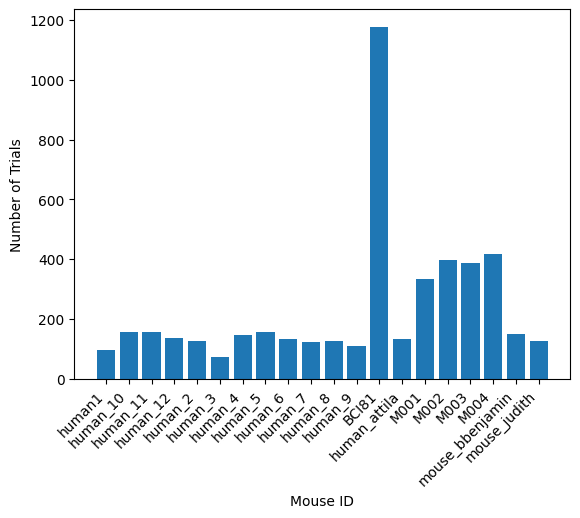

In [2]:
# find the mouse IDs that have been used in the experiment and count the number of trials for each mouse, then plot a bar graph
mouse_IDs = lab.Subject.fetch('subject_id')
trial_nums = []
for m in mouse_IDs:
    trial_nums.append(len((experiment.SessionTrial()&{'subject_id':m})))
trial_nums = np.array(trial_nums)
needed_mice = trial_nums>0

fig = plt. figure()
plt.bar(mouse_IDs[needed_mice], trial_nums[needed_mice])
plt.xticks(rotation=45, ha="right")
plt.xlabel('Mouse ID')
plt.ylabel('Number of Trials')


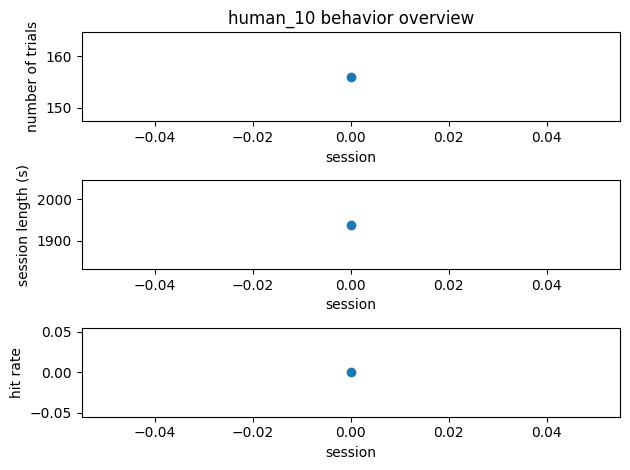

In [4]:

#subject_id = 'M004'#'mouse_bbenjamin'#'BCI81'
subject_id = 'mouse_judith'
#subject_id = 'mouse_bbenjamin'
subject_id = 'human_10'

available_sessions = (experiment.Session()&{'subject_id':subject_id}).fetch('session')
trial_nums = []
hit_rates = []
session_lengths = []
for session in available_sessions:
    trials = (experiment.SessionTrial()&{'subject_id':subject_id,
                                         'session':session}).fetch('trial')
    trial_nums.append(len(trials))
    hits = len(experiment.BehaviorTrial()&{'subject_id':subject_id,'session':session,'outcome':'hit'})
    hit_rate = hits/len(trials) if len(trials)>0 else np.nan
    hit_rates.append(hit_rate)
    session_length = (experiment.SessionTrial()&{'subject_id':subject_id,'session':session,'trial':np.max(trials)}).fetch1('trial_end_time')
    session_lengths.append(session_length)
fig = plt.figure()
ax1 = fig.add_subplot(3,1,1)
ax1.plot(available_sessions,trial_nums,'o-')
ax1.set_xlabel('session')
ax1.set_ylabel('number of trials')
plt.title(f'{subject_id} behavior overview')
ax2 = fig.add_subplot(3,1,2)
ax2.plot(available_sessions,session_lengths,'o-')
ax2.set_xlabel('session')
ax2.set_ylabel('session length (s)')
ax3 = fig.add_subplot(3,1,3)
ax3.plot(available_sessions,hit_rates,'o-')
ax3.set_xlabel('session')
ax3.set_ylabel('hit rate')
plt.tight_layout()
plt.show()

C:\Users\labadmin\AppData\Local\Temp\ipykernel_66696\587861719.py:78: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_66696\587861719.py:78: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_66696\587861719.py:78: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_66696\587861719.py:78: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_66696\587861719.py:78: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_66696\587861719.py:78: RuntimeWarning: divide by zero encountered in

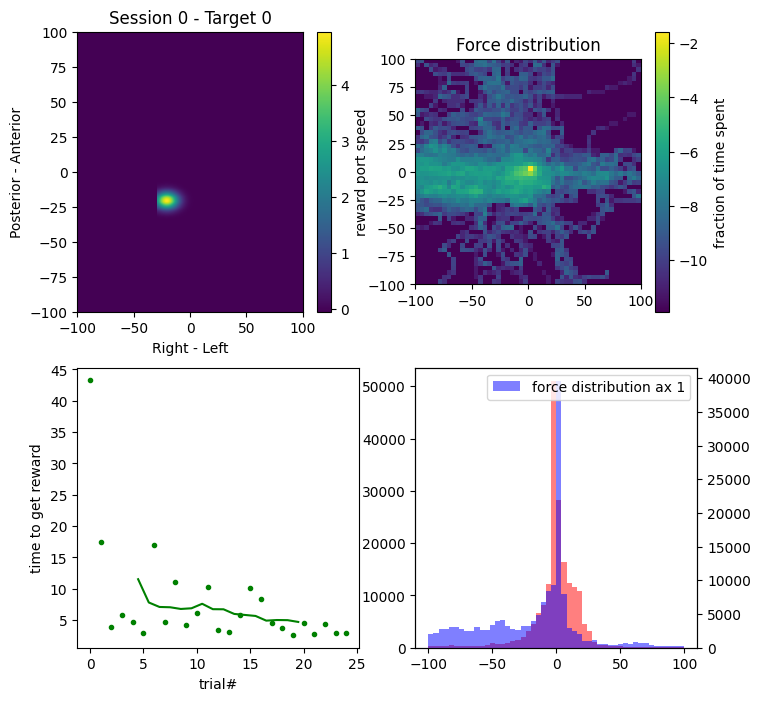

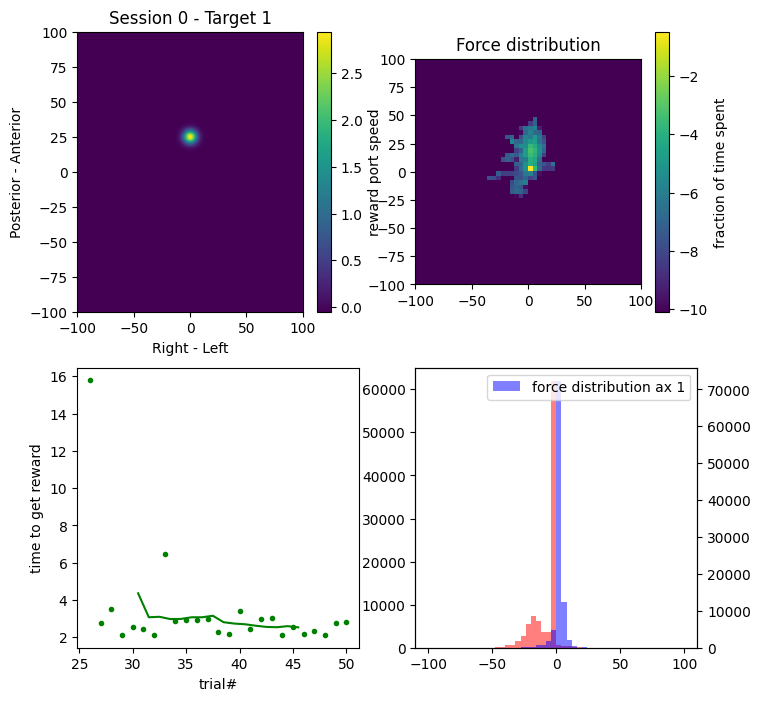

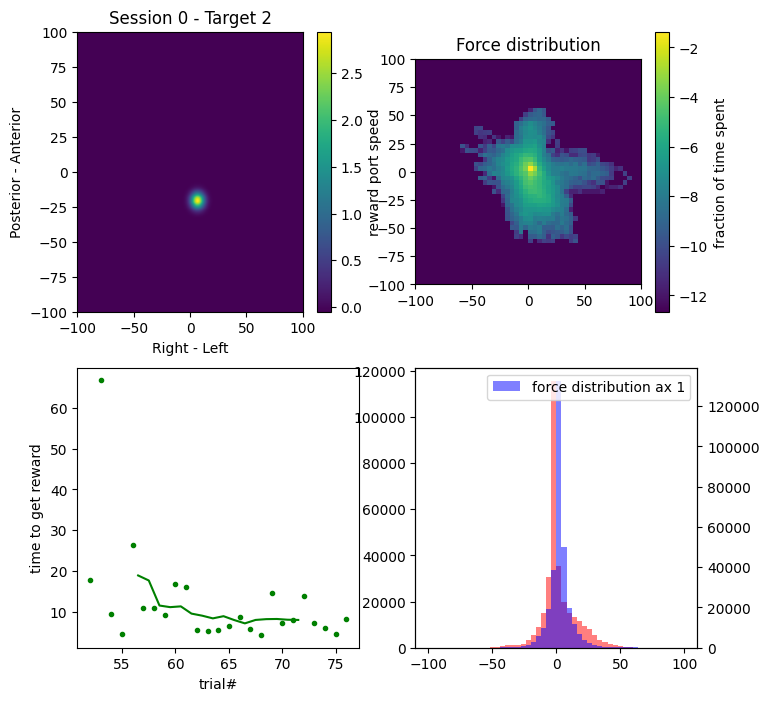

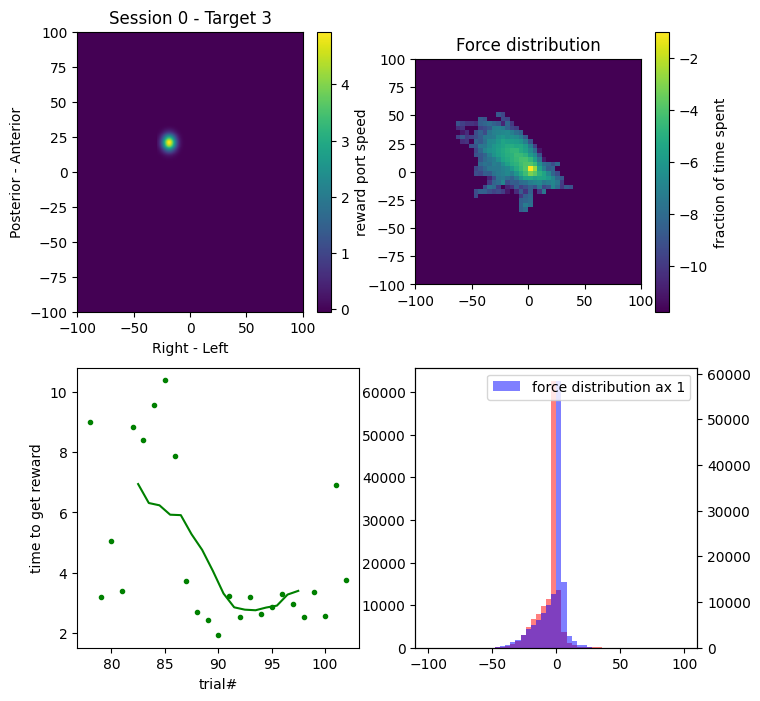

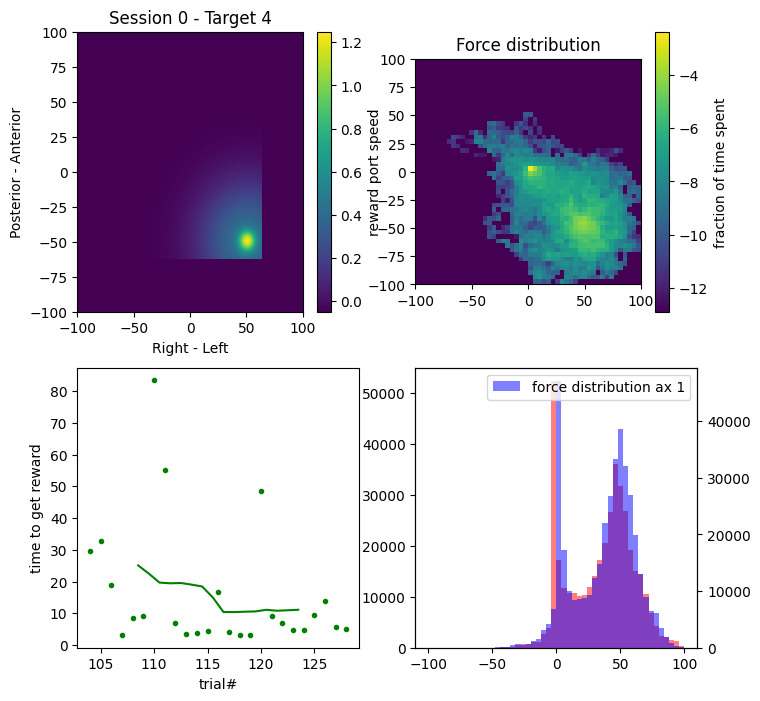

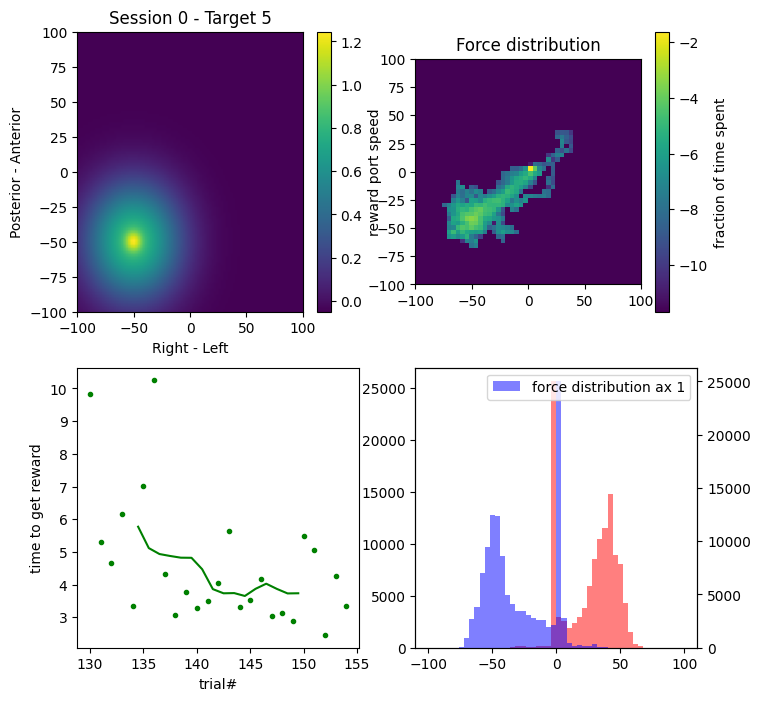

In [6]:
# visualize targets, and how forces change over sessions and trials
import matplotlib.pyplot as plt
subtract_force_median = False
force_uniform_range = True
uniform_force_range= np.asarray([-1,1,-1,1])*100

for session_i, session in enumerate(available_sessions):
    

    
    task_setting_ids,target_force_luts = (experiment.TaskSettings()&{'subject_id':subject_id,'session':session}).fetch('task_setting_id','target_force_lut')
    force_axes = (experiment.TaskSettings.ForceAxis()&{'subject_id':subject_id,'session':session}).fetch(as_dict=True)
    for task_setting_id,target_force_lut in zip(task_setting_ids,target_force_luts):
        fig = plt.figure(figsize=(8,8))
        ax_target_LUT = fig.add_subplot(2,2,1)
        force_axes_dict = {}
        for fa in force_axes:
            if fa['task_setting_id'] == task_setting_id:
                force_axes_dict[fa['force_axis_idx']] = {'force_direction':fa['force_direction'],
                                                    'target_force_axes':fa['target_force_axes']}
        if force_uniform_range:
            im0 = plt.imshow(np.ones(target_force_lut.shape)*np.min(target_force_lut.flatten()),extent = uniform_force_range,alpha = 1)                                            
        im_lut = plt.imshow(target_force_lut,extent = [force_axes_dict[0]['target_force_axes'][0],force_axes_dict[0]['target_force_axes'][-1],
                                                    force_axes_dict[1]['target_force_axes'][0],force_axes_dict[1]['target_force_axes'][-1]],
                                                    origin='upper',
                                                    cmap='viridis',
                                                    aspect='auto')
        plt.xlabel(direction_dict[force_axes_dict[0]['force_direction']])
        plt.ylabel(direction_dict[force_axes_dict[1]['force_direction']])
        plt.colorbar(im_lut,label='reward port speed')
        plt.title(f'Session {session} - Target {task_setting_id}')
        if force_uniform_range:
            ax_target_LUT.set_xlim([uniform_force_range[0],uniform_force_range[1]])
            ax_target_LUT.set_ylim([uniform_force_range[2],uniform_force_range[3]])


        ax_performance = fig.add_subplot(2,2,3)
        rewarded_trial, time_to_reward = (experiment.TrialEvent()*experiment.BehaviorTrial()*experiment.TaskSettings()&{'subject_id':subject_id,'session':session,'trial_event_type':'threshold crossing','task_setting_id':task_setting_id}).fetch('trial','trial_event_time')    #break
        ax_performance.set_xlabel('trial#')
        ax_performance.plot(rewarded_trial,time_to_reward,'g.')
        if len(rewarded_trial)>10:
            ax_performance.plot(np.convolve(rewarded_trial,np.ones(10)/10,mode='valid'),
                                np.convolve(np.asarray(time_to_reward,float),np.ones(10)/10,mode='valid'),'g-')
        
        ax_performance.set_ylabel('time to get reward')
        
        ax_force_hist = fig.add_subplot(2,2,2)
        force_traces_0_ = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings()&{'subject_id':subject_id,'session':session,'force_axis_idx':0,'task_setting_id':task_setting_id}).fetch('force_trace_value')
        force_traces_1_ = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'force_axis_idx':1,'task_setting_id':task_setting_id}).fetch('force_trace_value')
        if subtract_force_median:
            f0_baseline = np.median(np.concatenate(force_traces_0_))
            f1_baseline = np.median(np.concatenate(force_traces_1_))
            force_traces_0 = []
            for f in  force_traces_0_:
                force_traces_0.append(f-f0_baseline)
            force_traces_1 = []
            for f in  force_traces_1_:
                force_traces_1.append(f-f1_baseline)
        else:
            force_traces_0 = force_traces_0_
            force_traces_1 = force_traces_1_
        

        if force_uniform_range:
            histrange = [uniform_force_range[:2],uniform_force_range[:2]]
        else:
            histrange = [[force_axes_dict[0]['target_force_axes'][0],
                        force_axes_dict[0]['target_force_axes'][-1]],
                        [force_axes_dict[1]['target_force_axes'][0],
                        force_axes_dict[1]['target_force_axes'][-1]]]
        
        try:
            forcehist,binx,biny = np.histogram2d(np.concatenate(force_traces_0),
                                                np.concatenate(force_traces_1),
                                                range=histrange,
                                                bins=50)
            forcehist_all = forcehist.copy()
            forcehist = np.log(forcehist/sum(forcehist.flatten()))
            forcehist_ = forcehist.copy()
            forcehist_ [np.isinf(forcehist )] = 0
            forcehist[np.isinf(forcehist)] = np.nanmin(forcehist_.flatten())
            im_hist = ax_force_hist.imshow(forcehist,
                                        extent = [binx[0],binx[-1],biny[0],biny[-1]],
                                            alpha = 1)
            plt.colorbar(im_hist,label = 'fraction of time spent')
        except:
            pass

        plt.title('Force distribution')

        ax_force_hist_1d = fig.add_subplot(2,2,4)
        ax_force_hist_1d_2 = ax_force_hist_1d.twinx()
        try:
            ax_force_hist_1d.hist(np.concatenate(force_traces_0),binx,color = 'red',alpha = .5,label = 'force distribution ax 0')
            ax_force_hist_1d_2.hist(np.concatenate(force_traces_1),biny,color = 'blue',alpha = .5,label = 'force distribution ax 1')
            plt.legend()
            plt.xlabel('Force values')
        except:
            pass
        #ax_performance.set_yscale('log')
    

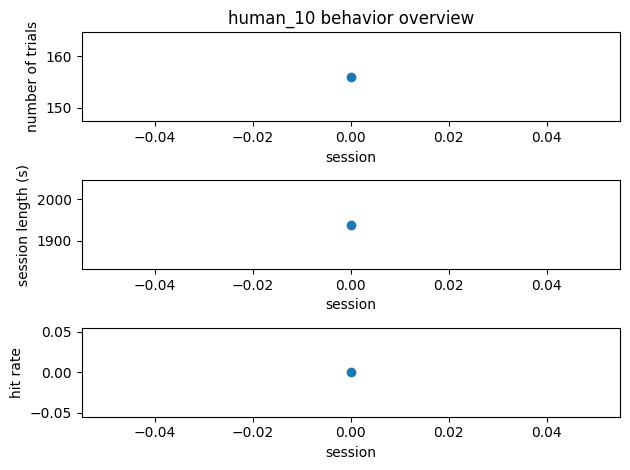

C:\Users\labadmin\AppData\Local\Temp\ipykernel_66696\952036894.py:103: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_66696\952036894.py:103: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_66696\952036894.py:103: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_66696\952036894.py:103: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_66696\952036894.py:103: RuntimeWarning: divide by zero encountered in log
  forcehist = np.log(forcehist/sum(forcehist.flatten()))
C:\Users\labadmin\AppData\Local\Temp\ipykernel_66696\952036894.py:103: RuntimeWarning: divide by zero encounte

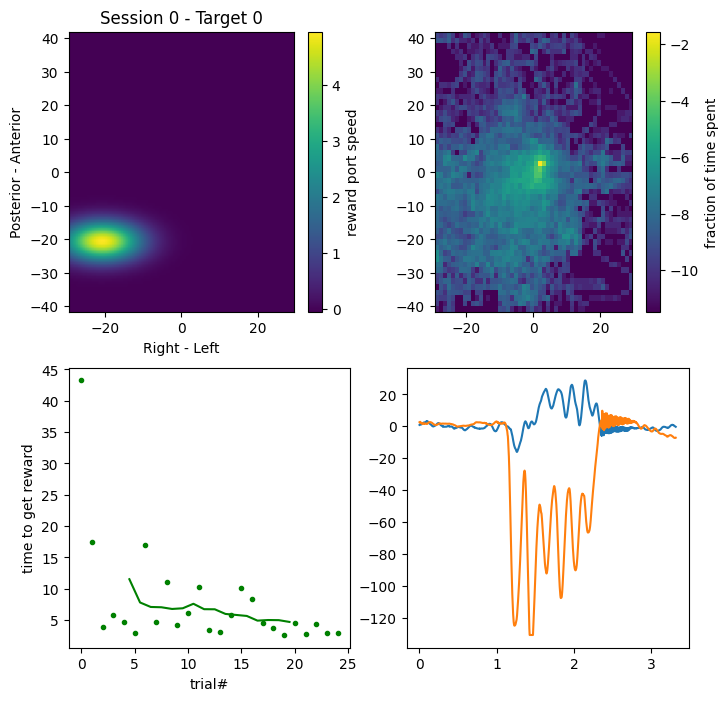

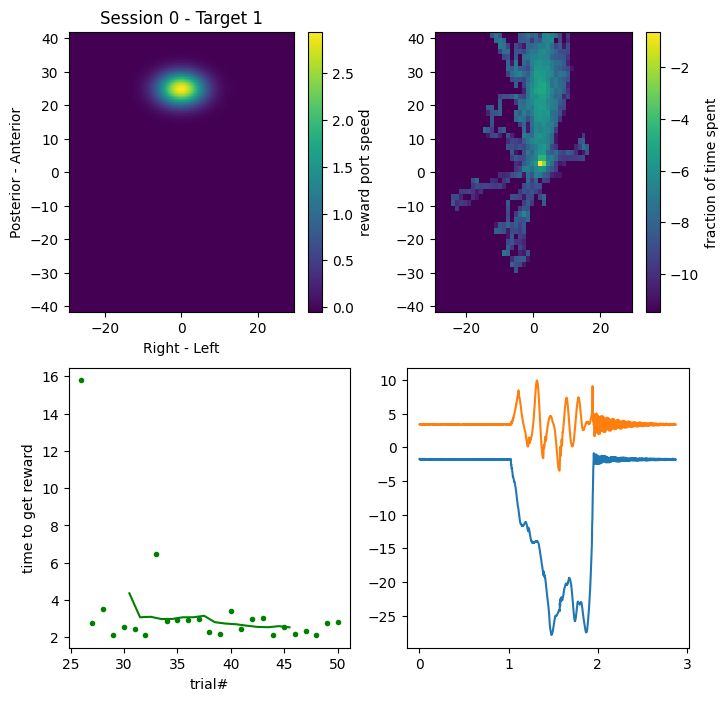

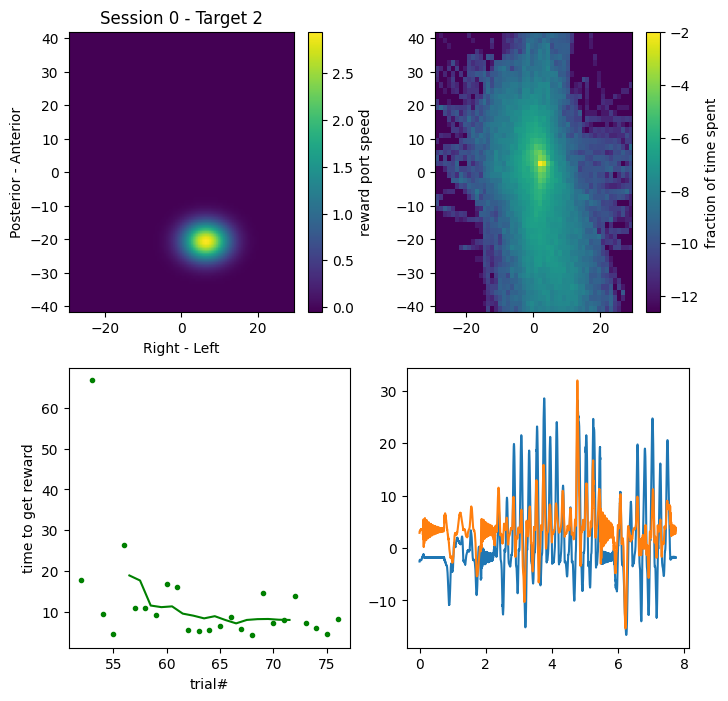

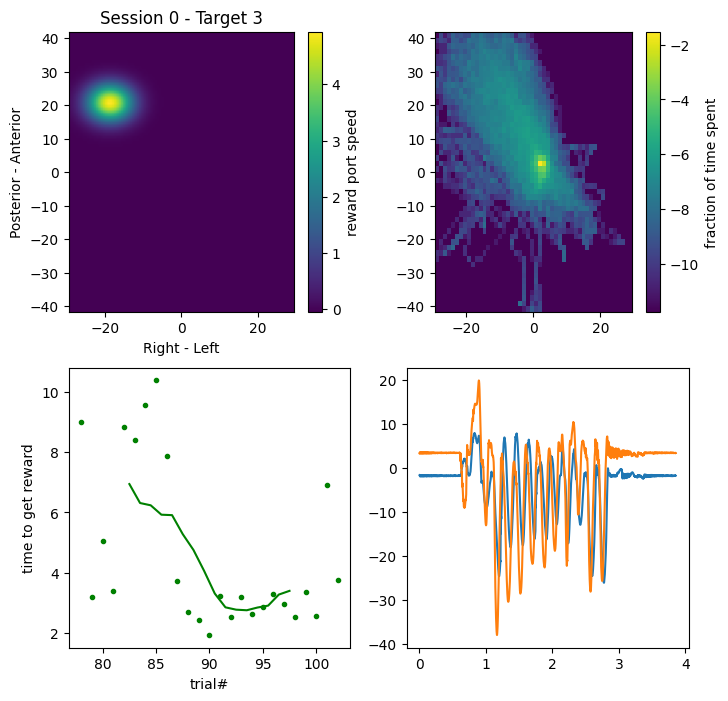

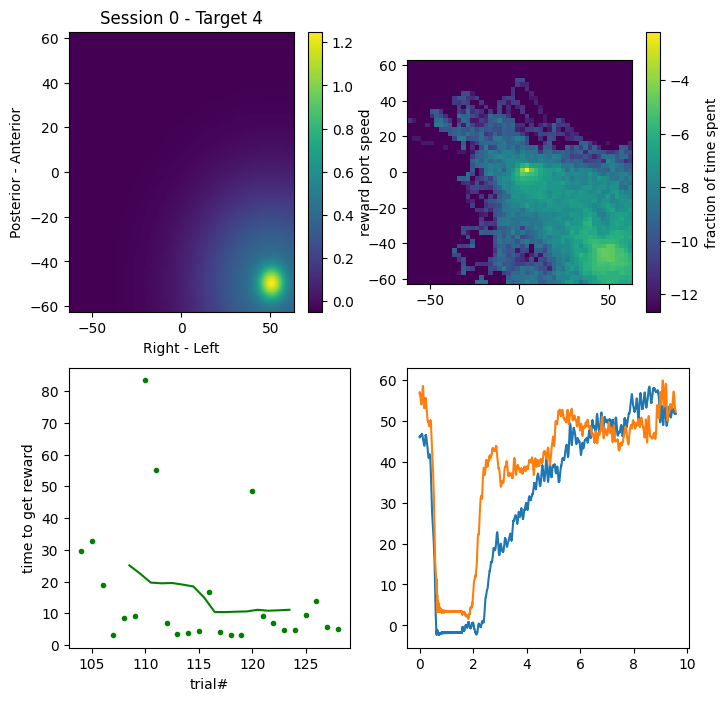

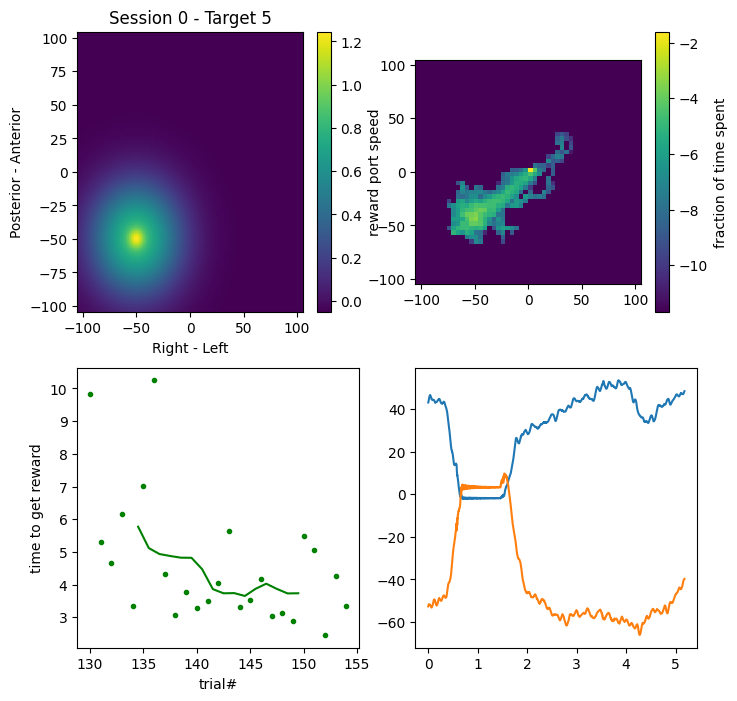

In [7]:

subject_id = 'human_attila'
subject_id = 'human_10'
available_sessions = (experiment.Session()&{'subject_id':subject_id}).fetch('session')
trial_nums = []
hit_rates = []
session_lengths = []
for session in available_sessions:
    trials = (experiment.SessionTrial()&{'subject_id':subject_id,
                                         'session':session}).fetch('trial')
    trial_nums.append(len(trials))
    hits = len(experiment.BehaviorTrial()&{'subject_id':subject_id,'session':session,'outcome':'hit'})
    hit_rate = hits/len(trials) if len(trials)>0 else np.nan
    hit_rates.append(hit_rate)
    session_length = (experiment.SessionTrial()&{'subject_id':subject_id,'session':session,'trial':np.max(trials)}).fetch1('trial_end_time')
    session_lengths.append(session_length)
fig = plt.figure()
ax1 = fig.add_subplot(3,1,1)
ax1.plot(available_sessions,trial_nums,'o-')
ax1.set_xlabel('session')
ax1.set_ylabel('number of trials')
plt.title(f'{subject_id} behavior overview')
ax2 = fig.add_subplot(3,1,2)
ax2.plot(available_sessions,session_lengths,'o-')
ax2.set_xlabel('session')
ax2.set_ylabel('session length (s)')
ax3 = fig.add_subplot(3,1,3)
ax3.plot(available_sessions,hit_rates,'o-')
ax3.set_xlabel('session')
ax3.set_ylabel('hit rate')
plt.tight_layout()
plt.show()


# visualize targets, and how forces change over sessions and trials
import matplotlib.pyplot as plt
subtract_force_median = False
force_uniform_range = False
uniform_force_range= np.asarray([-1,1,-1,1])*100

for session_i, session in enumerate(available_sessions):
    task_setting_ids,target_force_luts = (experiment.TaskSettings()&{'subject_id':subject_id,'session':session}).fetch('task_setting_id','target_force_lut')
    force_axes = (experiment.TaskSettings.ForceAxis()&{'subject_id':subject_id,'session':session}).fetch(as_dict=True)
    for task_setting_id,target_force_lut in zip(task_setting_ids,target_force_luts):
        fig = plt.figure(figsize=(8,8))
        ax_target_LUT = fig.add_subplot(2,2,1)
        force_axes_dict = {}
        for fa in force_axes:
            if fa['task_setting_id'] == task_setting_id:
                force_axes_dict[fa['force_axis_idx']] = {'force_direction':fa['force_direction'],
                                                    'target_force_axes':fa['target_force_axes']}
        if force_uniform_range:
            im0 = plt.imshow(np.ones(target_force_lut.shape)*np.min(target_force_lut.flatten()),extent = uniform_force_range,alpha = 1)                                            
        im_lut = plt.imshow(target_force_lut,extent = [force_axes_dict[0]['target_force_axes'][0],force_axes_dict[0]['target_force_axes'][-1],
                                                    force_axes_dict[1]['target_force_axes'][0],force_axes_dict[1]['target_force_axes'][-1]],
                                                    origin='upper',
                                                    cmap='viridis',
                                                    aspect='auto')
        plt.xlabel(direction_dict[force_axes_dict[0]['force_direction']])
        plt.ylabel(direction_dict[force_axes_dict[1]['force_direction']])
        plt.colorbar(im_lut,label='reward port speed')
        plt.title(f'Session {session} - Target {task_setting_id}')

        
        if force_uniform_range:
            ax_target_LUT.set_xlim([uniform_force_range[0],uniform_force_range[1]])
            ax_target_LUT.set_ylim([uniform_force_range[2],uniform_force_range[3]])


        ax_performance = fig.add_subplot(2,2,3)
        rewarded_trial, time_to_reward = (experiment.TrialEvent()*experiment.BehaviorTrial()*experiment.TaskSettings()&{'subject_id':subject_id,'session':session,'trial_event_type':'threshold crossing','task_setting_id':task_setting_id}).fetch('trial','trial_event_time')    #break
        ax_performance.set_xlabel('trial#')
        ax_performance.plot(rewarded_trial,time_to_reward,'g.')
        if len(rewarded_trial)>10:
            ax_performance.plot(np.convolve(rewarded_trial,np.ones(10)/10,mode='valid'),
                                np.convolve(np.asarray(time_to_reward,float),np.ones(10)/10,mode='valid'),'g-')
        
        ax_performance.set_ylabel('time to get reward')
        


        ax_force_hist = fig.add_subplot(2,2,2)
        force_traces_0 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings()&{'subject_id':subject_id,'session':session,'force_axis_idx':0,'task_setting_id':task_setting_id}).fetch('force_trace_value')
        force_traces_1 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'force_axis_idx':1,'task_setting_id':task_setting_id}).fetch('force_trace_value')
        force_traces_2 = (experiment.TrialForceTrace.TrialForceAxis()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'force_axis_idx':2,'task_setting_id':task_setting_id}).fetch('force_trace_value')
        force_trace_time = (experiment.TrialForceTrace()*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'task_setting_id':task_setting_id}).fetch('force_trace_time')
        reward_port_time, reward_port_position = (experiment.TrialRewardPortPosition*experiment.BehaviorTrial()*experiment.TaskSettings() &{'subject_id':subject_id,'session':session,'task_setting_id':task_setting_id}).fetch('reward_port_position_time','reward_port_position_values')


        if force_uniform_range:
            histrange = [uniform_force_range[:2],uniform_force_range[:2]]
        else:
            histrange = [[force_axes_dict[0]['target_force_axes'][0],
                        force_axes_dict[0]['target_force_axes'][-1]],
                        [force_axes_dict[1]['target_force_axes'][0],
                        force_axes_dict[1]['target_force_axes'][-1]]]
        
        try:
            forcehist,binx,biny = np.histogram2d(np.concatenate(force_traces_0),
                                                np.concatenate(force_traces_1),
                                                range=histrange,
                                                bins=50)
            forcehist_all = forcehist.copy()
            forcehist = np.log(forcehist/sum(forcehist.flatten()))
            forcehist_ = forcehist.copy()
            forcehist_ [np.isinf(forcehist )] = 0
            forcehist[np.isinf(forcehist)] = np.nanmin(forcehist_.flatten())
            im_hist = ax_force_hist.imshow(forcehist,
                                        extent = [binx[0],binx[-1],biny[0],biny[-1]],
                                            alpha = 1)
            plt.colorbar(im_hist,label = 'fraction of time spent')
        except:
            pass


        ax1 = fig.add_subplot(2,2,4)
#        ax1 = plt.subplot(1,1,1)
        trial_to_show = len(force_traces_0)-5

        try:
            ax1.plot(force_trace_time[trial_to_show],force_traces_0[trial_to_show],label=direction_dict[force_axes_dict[0]['force_direction']])
            ax1.plot(force_trace_time[trial_to_show],force_traces_1[trial_to_show],label=direction_dict[force_axes_dict[1]['force_direction']])
        #ax1.plot(force_trace_time[trial_to_show],force_traces_2[trial_to_show],label='dorsoventral')#direction_dict[force_axes_dict[2]['force_direction']]
        except:
            pass

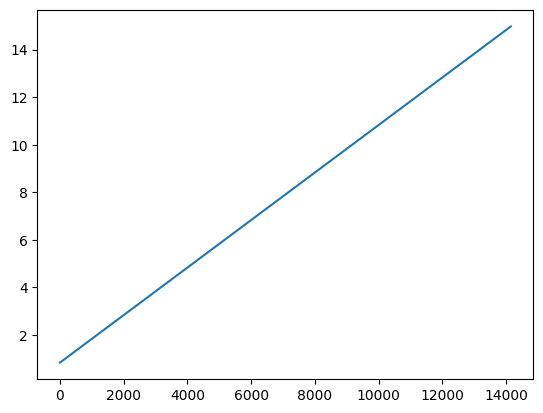

In [160]:
plt.plot(reward_port_time[0])

In [164]:
np.concatenate(reward_port_time[needed_trials])

array([0.622016, 0.622016, 0.624032, ..., 4.749984, 4.749984, 4.752   ],
      shape=(76692,))

Text(0, 0.5, 'distance from start')

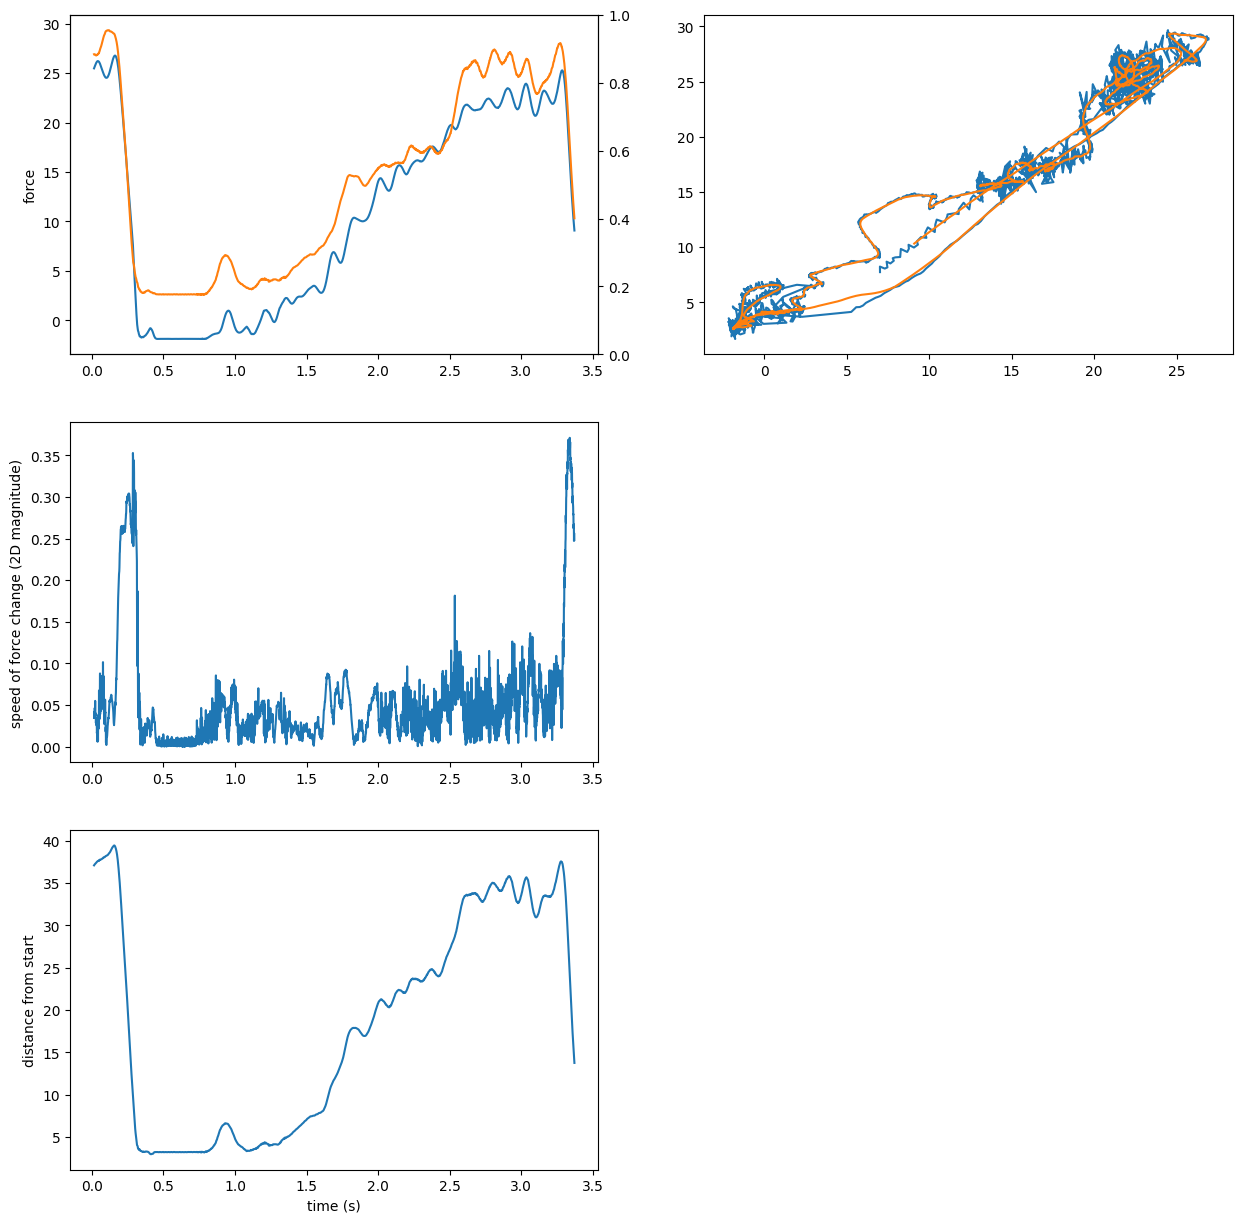

In [ ]:
smooth_window = 30
sd_window = 60
threshold_distance_for_hold = 40
needed_trials = [18]#,12,13,14,15,16]#,12,13,14]

fig= plt.figure(figsize = [15,15])
ax1 = fig.add_subplot(3,2,1)
ax1_position = ax1.twinx()
ax2 = fig.add_subplot(3,2,2)
ax3 = fig.add_subplot(3,2,3,sharex=ax1)
ax_sd = fig.add_subplot(3,2,5,sharex=ax1)
force_trace_0 = np.concatenate(force_traces_0[needed_trials])
force_trace_1 = np.concatenate(force_traces_1[needed_trials])

reward_port_time_now = np.concatenate(reward_port_time[needed_trials])
reward_port_position_now = np.concatenate(reward_port_position[needed_trials])
reward_port_time_now =  np.arange(len(reward_port_position_now))*np.median(np.diff(np.concatenate(reward_port_time[needed_trials])[::2])/2)

force_trace_0_smooth = np.convolve(force_trace_0,np.ones(smooth_window)/smooth_window,mode='valid')
force_trace_1_smooth = np.convolve(force_trace_1,np.ones(smooth_window)/smooth_window,mode='valid')
force_trace_0_sd =  pd.Series(force_trace_0_smooth).rolling(window=sd_window).std()
force_trace_1_sd =  pd.Series(force_trace_1_smooth).rolling(window=sd_window).std()

distance_from_start = np.sqrt(np.concatenate(force_traces_0[needed_trials])**2+np.concatenate(force_traces_1[needed_trials])**2)
distance_from_start_smooth = np.convolve(distance_from_start,np.ones(smooth_window)/smooth_window,mode='valid')

holding_times = distance_from_start_smooth>threshold_distance_for_hold



force_time = np.arange(len(force_trace_0))*np.median(np.diff(np.concatenate(force_trace_time)))
force_time_smooth = np.convolve(force_time,np.ones(smooth_window)/smooth_window,mode='valid')

ax1.plot(force_time_smooth,force_trace_0_smooth,label=direction_dict[force_axes_dict[0]['force_direction']])
ax1.plot(force_time_smooth,force_trace_1_smooth,label=direction_dict[force_axes_dict[1]['force_direction']])
ax1.set_ylabel('force')
#ax1_position.plot(reward_port_time_now,reward_port_position_now,'k--',label='reward port position')

ax2.plot(force_trace_0,force_trace_1)
ax2.plot(force_trace_0_smooth,force_trace_1_smooth)
ax2.plot(force_trace_0_smooth[holding_times],force_trace_1_smooth[holding_times],'r.')


#ax3.plot(force_time_smooth[:-1],np.diff(force_trace_0_smooth),label=direction_dict[force_axes_dict[0]['force_direction']])
#ax3.plot(force_time_smooth[:-1],np.diff(force_trace_1_smooth),label=direction_dict[force_axes_dict[1]['force_direction']])
#ax3.set_ylabel('speed of force change')

d0 = np.diff(force_trace_0_smooth)
d1 = np.diff(force_trace_1_smooth)
speed_2d = np.sqrt(d0**2 + d1**2)

ax3.plot(force_time_smooth[:-1], speed_2d, label='2D force speed')
ax3.set_ylabel('speed of force change (2D magnitude)')


mean_sd = np.mean([force_trace_0_sd,force_trace_1_sd],axis=0)
ax_sd.plot(force_time_smooth,distance_from_start_smooth,label='distance')
ax_sd.plot(force_time_smooth[holding_times],distance_from_start_smooth[holding_times],color = 'red',label='holding times')
ax_sd.set_xlabel('time (s)')
ax_sd.set_ylabel('distance from start')
#ax_sd.plot(force_time_smooth,mean_sd,label='mean sd')
#
#ax_sd.plot(force_time_smooth,force_trace_0_sd,label=direction_dict[force_axes_dict[0]['force_direction']])
#ax_sd.plot(force_time_smooth,force_trace_1_sd,label=direction_dict[force_axes_dict[1]['force_direction']])
#plt.xlim([5,10])

Text(0, 0.5, 'speed of force change (2D magnitude)')

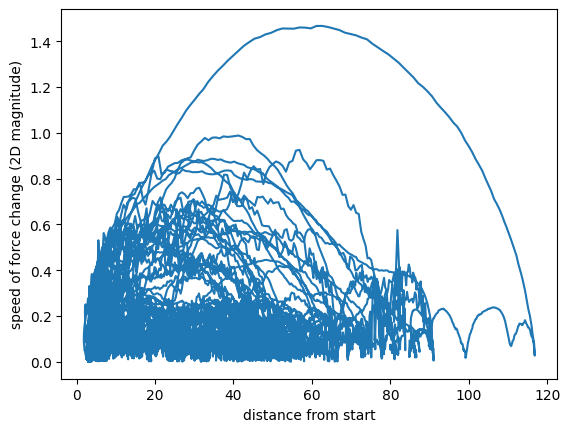

In [146]:
plt.plot(distance_from_start_smooth[:-1],speed_2d)
plt.xlabel('distance from start')
plt.ylabel('speed of force change (2D magnitude)')